# Jacobian using Jax and Flax Linen

In this notebook, we look at the dynamics predicted by the linearization about the 
$$
f(x, \theta) = f(x, \theta^*) + J_\theta (\theta - \theta^*) + \mathcal O(\theta^2)
$$
where $\theta^*$, ideally, is the global minimum. We should be able examine the spectrum of $H = J_\theta^T J_\theta$ (which is dimension $p \times p$ where $p$ is the number of parameters in $f(x, \theta)$.

The reason why $H$ is important is due to the gradient descent 
$$
\theta^{k+1} \approx \theta^k - \eta H \theta^K.
$$

Note that I'm using Linen and NOT the new nnx. nnx seems to be moving more towards the PyTorch model while I need the functional capabilities. 

## First some plotting and importing 

In [1]:
import os

os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
os.environ['JAX_PLATFORM_NAME'] = 'cpu'
os.environ['JAX_PLATFORMS']='cpu'

In [2]:
import jax
import jax.numpy as jnp
from flax import linen as nn
from typing import List
from flax.training import train_state  # Useful dataclass to keep train state
from flax import struct                # Flax dataclasses
import optax                           # Common loss functions and optimizers
import matplotlib.pyplot as plt
from flax.linen import initializers
from jax.tree_util import tree_map
from tqdm.notebook import tqdm
import numpy as np
from functools import partial
from dataclasses import dataclass
from typing import Union

# Really cool package for prototyping. 
import treescope
treescope.basic_interactive_setup()


In [3]:
def plot_results(state, history, x, y):
    # Plot the training loss
    plt.figure(figsize=(14, 5))
    plt.subplot(2, 2, 1)
    plt.semilogy(history['train_loss'])
    plt.xlabel('Iteration')
    plt.ylabel('Loss')
    plt.title('Training Loss')
    
    # Plot the eigenvalues
    plt.subplot(2, 2, 2)
    eigenvalues = np.array(history['eigs'])
    try: 
        for i in range(eigenvalues.shape[1]):
            plt.semilogy(eigenvalues[:, i], label=f'Eigenvalue {i+1}')
    except: 
        pass
    plt.xlabel('Iteration (x100)')
    plt.ylabel('Eigenvalue')
    plt.title('Eigenvalues of J^T J')
    # plt.legend()
    
    plt.subplot(2, 2, 3)
    plt.plot(x, state.apply_fn(state.params, x), 'x-')
    plt.plot(x, y, '.')
    plt.title('Train data versus model output')
    
    plt.subplot(2, 2, 4)
    # Extract LM results 
    indices = [i for i, item in enumerate(history['lm_data']) if item is not None]
    residuals = [item[0] for item in history['lm_data'] if item is not None]
    iterations = [item[1] for item in history['lm_data'] if item is not None]
    
    # Create a primary axis for residuals
    ax1 = plt.gca()
    color = 'tab:blue'
    ax1.set_xlabel('Index')
    ax1.set_ylabel('Residual', color=color)
    ax1.semilogy(indices, residuals, color=color, label='Residual')
    ax1.tick_params(axis='y', labelcolor=color)
    
    # Create a secondary y-axis for iteration counts
    ax2 = ax1.twinx()
    color = 'tab:red'
    ax2.set_ylabel('Iteration Count', color=color)
    ax2.plot(indices, iterations, color=color, label='Iteration Count')
    ax2.tick_params(axis='y', labelcolor=color)
    plt.tight_layout()
    plt.title('LM iteration data')
    plt.show()

    # Desired number of elements
    # step_size = max(1, len(eigevec) // 40)
    # joyplot(
    #     eigevec[::step_size],
    #     figsize=(14,5),
    #     overlap=0.8,
    #     colormap=plt.cm.viridis,
    #     fade=True,
    #     title="Ridge Plot of Largest Eigenvector Over Time", 
    #     # labels=[str(i) for i in np.arange(len(output[3]))],
    #     range_style='own'
    # )
    # plt.show()

    # eigenvalues = np.array(eigs_reg)
    # for i in range(eigenvalues.shape[1]):
    #     plt.semilogy(eigenvalues[:, i], label=f'Eigenvalue {i+1}')
    # plt.xlabel('Iteration (x100)')
    # plt.ylabel('Eigenvalue')
    # plt.title('Eigenvalues of J^T J + I')


## Calculation of Jacobian

There are multiple ways of doing it. We first consider the easiest way. 

We first use a simple analytical thing to compute and verify calculating the matrix $J_\theta$. 

Let $f(x, \theta) = \sin(Ax + b)$ where $A$ is just a row vector (e.g. the output is scalar). 
One can show that $J_\theta$ in this case is 
$$
J_\theta(x, \theta^*) = \cos(Ax + b) \begin{bmatrix} x_1 & x_2 & \cdots & x_n & 1 \end{bmatrix}
$$
where $x_i$ is the input dimension. 

In [4]:
# Define a simple model 
class Analytic(nn.Module):
    @nn.compact
    def __call__(self, x):
        return jnp.sin(nn.Dense(features=1)(x))

In [5]:
model = Analytic()
key = jax.random.key(0)
params = model.init(key, jnp.ones((3))) # Initialize parameters with a sample input

# Generate a random array with shape (5, 3)
x = jax.random.uniform(key, (5, 3))

In [6]:
def compute_jacobian(params, model, x):
    jacobian_fn = jax.jacrev(model.apply, argnums=0)
    return jacobian_fn(params, x)

# Might be able to use ravel eventually but this is easier
def flatten_jacobian(jacobian_dict, x):
    batch_size = x.shape[0]
    flat_jacobian = []
    for layer in jacobian_dict['params'].values():
        for param in layer.values():
            flat_jacobian.append(param.reshape(batch_size, -1))
    return jnp.concatenate(flat_jacobian, axis=1)

# Might be able to use ravel eventually but this is easier
def flatten_grad(grad_dict):
    batch_size = x.shape[0]
    flat_grad = []
    for layer in grad_dict['params'].values():
        for param in layer.values():
            flat_grad.append(param.reshape(-1))
    return jnp.concatenate(flat_grad)

jacob = compute_jacobian(params, model, x)

# Using this ravel is not the same matrix 
# flat_vector, unravel_fn = jax.flatten_util.ravel_pytree(jacob)
# print(flat_vector.reshape((5, -1)).T)
jacobian_jac = flatten_jacobian(jacob, x)
jacobian_jac

<jax.Array float32(5, 4) ≈0.52 ±0.28 [≥0.025, ≤0.97] nonzero:20
  <Arrayviz rendering>
| Device: CPU 0>

In [7]:
# Element-wise multiplication; true 
analytic = jnp.cos(
    jnp.matmul(x, params['params']['Dense_0']['kernel']) + params['params']['Dense_0']['bias']
) * jnp.hstack((jnp.ones((5, 1)),x))
print('This should be zero matrix')
analytic - jacobian_jac


This should be zero matrix


<jax.Array float32(5, 4) ≈0.0 ±0.0 [≥0.0, ≤0.0] zero:20
  <Arrayviz rendering>
| Device: CPU 0>

## What about in training context

Note that when training with the $L^2$ loss on residual, we naturally should be calculating the Jacobian. We will take advantage of this fact. 
$$
L = \frac{1}{2N} \sum (f(x_i, \theta) - y_i)^2 \implies \frac{\partial L}{\partial \theta} = \frac1N \sum (f(x_i, \theta) - y_i)\frac{\partial f(x_i, \theta)}{\partial \theta}
$$
Thus, the Jacobian is used alongside the residual to update. We want to be able to form this Jacobian and be able to perform gradient updates while being able to use it later to do CG updates or construct it if needed for analysis. 

We will write a sample training loop to see how this goes. 

Note that Flax/Linen is very functional, so we use the built-in TrainState to keep track of everything. 

Note that according to Autodiff Cookbook, jvp is VERY cheap; 3x cost of evaluating. vjp is a bit more difficult, but that's why we save it? 

## First define some Jax stuff for training

TrainState is used to pass around things, and need fast conjugate gradient. We also define a dataclass to store all the preconditioning information. 

In [8]:
key = jax.random.PRNGKey(0)


In [9]:
@dataclass(frozen=True) # Frozen for hashable
class PrecondData: 
    "Structure to store parameters for the precondtioning" 
    method: str = 'smw' # Default Sherman Morrison Williams
    epoch: int = 0 # Default apply from the 0th iteration 
    lamb: Union[float, str] = 0.1 # LM dynamics 
    line_search: bool = False # Line search or not

    # For GN
    thresh: float = 1e-3 
    
    # For CG: 
    max_iters: int = 100
    

In [10]:
# Create a TrainState which stores all the basic training needs; can pass eigs through here but will keep separate
class TrainState(train_state.TrainState):
    pass
    
def create_train_state(module, rng=None, learning_rate=1e-3, momentum=.9, optimizer='adam'):
    # Can be more careful with RNG; but this should be fine
    if rng is None: 
        rng = jax.random.key(0)

    # Init parameters
    params = module.init(rng, jnp.ones([1]))

    # Init optimizer
    if optimizer=='sgd':
        tx = optax.sgd(learning_rate, momentum)
    elif optimizer=='adamw':
        tx = optax.adamw(learning_rate)
    elif optimizer=='adam':
            tx = optax.adam(learning_rate)

    return TrainState.create(
        apply_fn=module.apply, 
        params=params, 
        tx=tx
    )

def batch_data(x, y, batch_size, rng_key):
    """Yield batches of data."""
    num_samples = x.shape[0]
    indices = jax.random.permutation(rng_key, num_samples)
    
    for start_idx in range(0, num_samples, batch_size):
        end_idx = min(start_idx + batch_size, num_samples)
        batch_indices = indices[start_idx:end_idx]
        yield x[batch_indices], y[batch_indices]
        

In [11]:
# Create standard model 
class MLP(nn.Module):
    num_layers: int = 2
    hidden_dim: int = 6

    @nn.compact
    def __call__(self, x):
        # Input x is expected to be of shape (batch_size, 1)
        for _ in range(self.num_layers):
            x = nn.Dense(features=self.hidden_dim, use_bias=True,
                    kernel_init=initializers.kaiming_uniform(),  # Kaiming uniform initialization
                    bias_init=initializers.zeros  # Bias initialized to zero
            )(x)
            x = nn.tanh(x)  # Apply activation function after each layer
        x = nn.Dense(features=1)(x)
        return x

In [12]:

def tree_dot(a, b):
    return jax.tree_util.tree_reduce(lambda x, y: x + y, 
                tree_map(lambda x, y: jnp.vdot(x, y), a, b)
    )

def conjugate_gradient(matvec, b, state, x, tol=1e-5, max_iter=1000):
    def body_fn(carry):
        k, r, p, rsold, i = carry
        Ap = matvec(p, state, x)
        alpha = rsold / tree_dot(p, Ap)
        k = tree_map(lambda k, p: k + alpha * p, k, p)
        r = tree_map(lambda r, Ap: r - alpha * Ap, r, Ap)
        rsnew = tree_dot(r, r)
        p = tree_map(lambda r, p: r + (rsnew / rsold) * p, r, p)
        return k, r, p, rsnew, i + 1

    def cond_fn(carry):
        _, _, _, rsnew, i = carry
        return jnp.logical_and(jnp.sqrt(rsnew) >= tol, i < max_iter)

    k = tree_map(jnp.zeros_like, b)  # Initial guess k = 0
    r = tree_map(lambda x: x, b)  # Initial residual r = b - A * k (A * k = 0 initially)
    p = tree_map(lambda x: x, r)  # Initial direction p = r
    rsold = tree_dot(r, r)

    init_carry = (k, r, p, rsold, 0)
    k, r, p, rsnew, i = jax.lax.while_loop(cond_fn, body_fn, init_carry)

    return k, (jnp.sqrt(rsnew), i) 

## Train function 

Use LM cycles to accelerate 

In [39]:
def train_model(state: TrainState, x, y, num_iterations:int = 1_000, 
        obtain_matrices: bool=False, 
        lm_schedule: PrecondData = None, batch_size=64
    ): 
    @jax.jit
    def model_output(params, x):
        # f(\theta, x); jax defaults to derivs of first component
        return state.apply_fn(params, x)

    # Explicitly computes \partial f/\partial \theta to compute gradient of error
    @jax.jit
    def compute_manual_gradient(state, x, y):
        # For MSE
        n = x.shape[0]

        # Compute the value of f(\theta, x) and the function for VJP
        preds, vjp_fn = jax.vjp(model_output, state.params, x)
        residuals = (preds - y)

        # Explicitly calculate loss for metrics
        loss = 1/n * jnp.sum(residuals ** 2)
        
        # residuals^T jacobian (Might need transpose here in 2D)
        manual_grad = vjp_fn(residuals * 2 / n)[0] # First term is wrt params

        return manual_grad, loss, vjp_fn

    # @partial(jax.jit, static_argnames='lm_info')
    def train_step(state, x, y, lm_info: PrecondData = None):
        # Manually calculate the gradient to demonstrate
        grads, loss, vjp_fn = compute_manual_gradient(state, x, y)

        # If lm information is passed in
        if lm_info:
            print(f'Running {lm_info.method}')
            if lm_info.method == 'exp': 
                r = 3
                # keys = jax.random.split(lm_info.key, r)
                key = jax.random.PRNGKey(0)
                keys = jax.random.split(key, r)
                
                temp, back = jax.flatten_util.ravel_pytree(grads)
                n = len(temp)
                m = len(x)

                # Generate 
                Omega = jnp.stack([jax.random.normal(keys[i], (n,)) for i in range(r + 1)], axis=1)
            
                Q = jnp.zeros((m, 0))
                for j in range(1, r+1):   
                    _, y_j = jax.jvp(lambda p:  state.apply_fn(p, x), (state.params,), (back(Omega[:, j]),)) 
                    y_j = jnp.squeeze(y_j)
                    # print(y_j, j)
                    # y_j = jnp.dot(A, Omega[:, j])      
                    # print(y_j, j)
            
                    y_j = y_j - jnp.dot(Q, jnp.dot(Q.T, y_j))
                    y_j = y_j / jnp.linalg.norm(y_j)
                    Q = jnp.hstack((Q, y_j[:, None]))
                    
                def apply_vjp_and_flatten(column): # Define a function that applies vjp_fn to a single column and flattens the result
                    column = column[:, jnp.newaxis] 
                    flat, _ = jax.flatten_util.ravel_pytree(vjp_fn(column)[0])
                    return flat

                # Use vmap to vectorize the function over the columns of Q
                B = jax.vmap(apply_vjp_and_flatten, in_axes=1, out_axes=0)(Q)    
                
                # Step 5
                Uhat, s_est, vh_est = jnp.linalg.svd(B)
                
                # Step 6
                # U_est = Q @ Uhat

                # Compute inverse
                threshold = 1e-3
                s_inv = jnp.where(s_est > lm_info.thresh, s_est**-2, threshold)
                print(s_inv)
                # Apply to grads
                # print(flatten_grad(grads))
                flattened, back = jax.flatten_util.ravel_pytree(grads)
                my_change = vh_est[0:len(s_inv), :].T @ jnp.diag(s_inv) @ vh_est[0:len(s_inv), :] @ flattened
                grads = back(my_change)
                lm_data = None
                
            elif lm_info.method == 'poly': 
                # P = tr(B)I - B where B is J^TJ ; don't solve anything
                jacobian_fn = flatten_jacobian(jax.jacrev(model_output)(state.params, x), x)
                B = jacobian_fn.T @ jacobian_fn
                # B2 = B @ B
    
                flattened, back = jax.flatten_util.ravel_pytree(grads)
                grads = back(
                    (jnp.trace(B) * jnp.eye(B.shape[0]) - B) @ flattened
                    # (.5 * ((jnp.trace(B) ** 2) - jnp.trace(B2)) * jnp.eye(B.shape[0]) - jnp.trace(B) * B + B2) @ flattened
                )
                lm_data = None
            elif lm_info.method == 'gn-exact': 
                # TODO: try https://arxiv.org/pdf/1905.11675
                # algorithim 1
                # move *beforeeee* 
                
                jacobian_fn = flatten_jacobian(jax.jacrev(model_output)(state.params, x), x)
                print(jacobian_fn[0, :])

                # Compute SVD
                u, s, vh = jnp.linalg.svd(jacobian_fn, full_matrices=False) 
    
                # Compute inverse
                threshold = 1e-3
                s_inv = jnp.where(s > lm_info.thresh, s**-2, threshold)
                print(f'{s_inv=}')
    
                # Apply to grads
                # print(flatten_grad(grads))
                flattened, back = jax.flatten_util.ravel_pytree(grads)
                # print(flattened)
                my_change = vh.T @ jnp.diag(s_inv) @ vh @ flattened
                grads = back(my_change)
                lm_data = None
                
            elif lm_info.method == 'smw':            
                # For ease of access
                lamb = lm_info.lamb
    
                # J \vec k
                _, jvp_output = jax.jvp(lambda p: state.apply_fn(p, x), (state.params,), (grads,)) 
    
                # Construct and compute (I + 1/lambda JJ^T)^{-1} (Jv)
                jacobian_fn = flatten_jacobian(jax.jacrev(model_output)(state.params, x), x)
                mat = jacobian_fn @ jacobian_fn.T
                out = jnp.linalg.solve(jnp.eye(mat.shape[0]) + 1 / lamb * mat, jvp_output / (lamb ** 2))
    
                adjustment = vjp_fn(out)[0]
    
                grads = tree_map(lambda a, b: 1 / lamb * a - b, grads, adjustment)
                lm_data = None
            elif lm_info.method == 'cg':
                # Define mat-vec for (\lambda I + J^T J)
                # Matrix-free implementation; we use vjp_fn computed above and jvp is cheap 
                def matvec(k, state, x):
                    # Compute J^T J k using jvp and vjp
                    _, jvp_output = jax.jvp(lambda p: state.apply_fn(p, x), (state.params,), (k,))
                    Av = vjp_fn(jvp_output)[0]
        
                    # Add the regularization term lambda * k
                    Av = tree_map(lambda a, b: a + lm_info.lamb * b, Av, k)
                    return Av
                    
                grads, lm_data = conjugate_gradient(matvec, grads, state, x, max_iter=lm_info.max_iters)
            else: 
                raise Exception('Not a method')
        else:
            lm_data = None
            
        # Apply the gradient update
        state = state.apply_gradients(grads=grads)

        return state, loss, lm_data

    @jax.jit
    def get_eigs(state, x, return_matrix: bool=True):
        """
        Only really for diagnostics
        """
        # Calculate explicitly 
        jacobian_fn = flatten_jacobian(jax.jacrev(model_output)(state.params, x), x)
        mat = jacobian_fn.T @ jacobian_fn
        eigs = jnp.linalg.eigvalsh(mat)

        if return_matrix:
            return {'eigs': eigs, 'mat': jacobian_fn}
        else:
            return {'eigs': eigs}
    
    metrics_history = {
        'train_loss': [], 'eigs': [], 'mat': [],
        'lm_data': [],
    }

    rng_key = jax.random.PRNGKey(0)

    for epoch in tqdm(range(num_iterations), leave=True):
        # Jax randomness kinda sucks; but this ensures that each epoch the batches are diff
        rng_key, subkey = jax.random.split(rng_key)

        epoch_loss = 0
        num_batches = 0
        
        for x_batch, y_batch in batch_data(x, y, batch_size, subkey):
            print(x_batch, y_batch)
            if lm_schedule and epoch >= lm_schedule.epoch:
                state, loss, lm_data = train_step(state, x_batch, y_batch, lm_schedule)
            else: 
                state, loss, lm_data = train_step(state, x_batch, y_batch)
            epoch_loss += loss
            num_batches += 1
        # break
        # Compute the average loss for the epoch
        avg_loss = epoch_loss / num_batches
        metrics_history['train_loss'].append(avg_loss)
        metrics_history['lm_data'].append(lm_data)

        if (epoch % 100) == 0: 
            if obtain_matrices:
                out = get_eigs(state, x)
                
                for key in out.keys():
                    metrics_history[key].append(out[key])

    return state, metrics_history
    

## Experiments 

This is not a silver bullet; first, batched SGD; takes long time. seems to need tunining; no momentum is BAD

Better to do a switch or something 

  0%|          | 0/10000 [00:00<?, ?it/s]

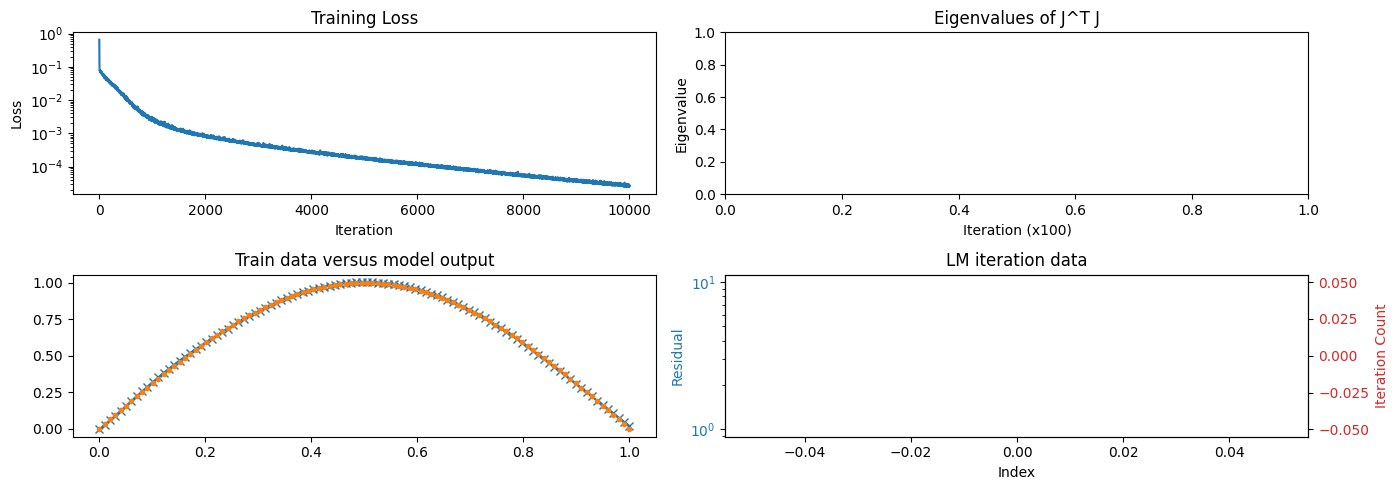

In [14]:
x = jnp.linspace(0, 1, 100).reshape(-1, 1)
y = jnp.sin(1  * jnp.pi * x)
# model = MLP(num_layers=8,hidden_dim=24)
model = MLP(num_layers=4,hidden_dim=10)
key = jax.random.PRNGKey(0)
lm_info = PrecondData(
    method='gn-exact', epoch=0, lamb=1e-1,
    # thresh=1e-1
    # key=key
)

state = create_train_state(model, learning_rate=1e-2, momentum=0, optimizer='sgd')
state, metrics_history = train_model(state, x, y, num_iterations=10000, obtain_matrices=False, 
                                     lm_schedule=None,
                                    )
plot_results(state, metrics_history, x, y)

# print(model.tabulate(
#     jax.random.key(0), x, compute_flops=True, compute_vjp_flops=True
# ))
# 

  0%|          | 0/10000 [00:00<?, ?it/s]

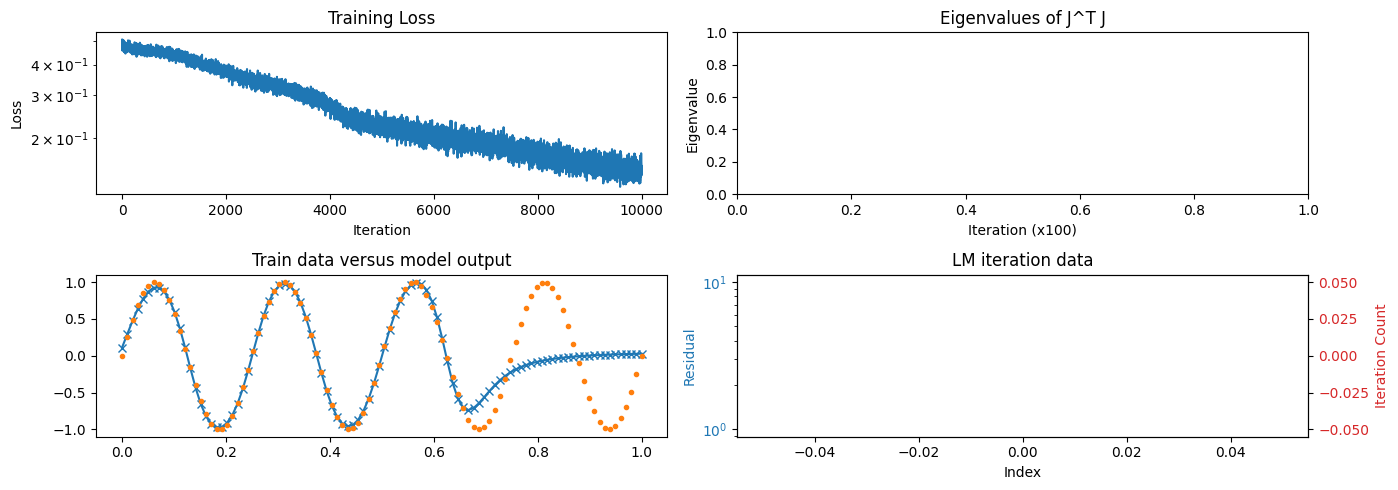

In [15]:
x = jnp.linspace(0, 1, 100).reshape(-1, 1)
y = jnp.sin(8  * jnp.pi * x)
# model = MLP(num_layers=8,hidden_dim=24)
model = MLP(num_layers=4,hidden_dim=10)
key = jax.random.PRNGKey(0)
lm_info = PrecondData(
    method='gn-exact', epoch=0, lamb=1e-1,
    # thresh=1e-1
    # key=key
)

state = create_train_state(model, learning_rate=1e-2, momentum=0, optimizer='sgd')
state, metrics_history_high = train_model(state, x, y, num_iterations=10000, obtain_matrices=False, 
                                     lm_schedule=None,
                                    )
plot_results(state, metrics_history_high, x, y)

# print(model.tabulate(
#     jax.random.key(0), x, compute_flops=True, compute_vjp_flops=True
# ))
# 

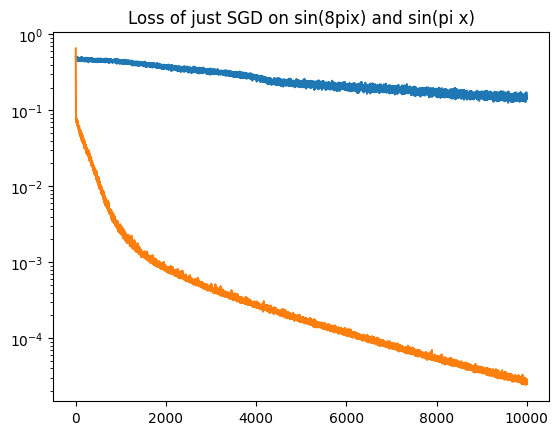

In [16]:
plt.semilogy(metrics_history_high['train_loss'])
plt.semilogy(metrics_history['train_loss'])
plt.title('Loss of just SGD on sin(8pix) and sin(pi x)')
plt.show()

  0%|          | 0/1 [00:00<?, ?it/s]

[[0.989899  ]
 [0.43434343]
 [0.22222222]
 [0.94949496]
 [0.86868685]
 [0.4949495 ]
 [0.        ]
 [0.45454547]
 [0.56565654]
 [0.6262626 ]
 [0.03030303]
 [0.7777778 ]
 [0.09090909]
 [0.64646465]
 [0.05050505]
 [0.5252525 ]
 [0.5050505 ]
 [0.37373737]
 [0.7878788 ]
 [0.959596  ]
 [0.3030303 ]
 [0.7171717 ]
 [0.53535354]
 [0.34343433]
 [0.83838385]
 [0.18181819]
 [0.14141414]
 [0.46464646]
 [0.01010101]
 [0.74747473]
 [0.5858586 ]
 [0.9292929 ]
 [0.5151515 ]
 [0.8181818 ]
 [0.4848485 ]
 [0.42424244]
 [0.08080808]
 [0.6969697 ]
 [0.90909094]
 [0.6666667 ]
 [0.65656567]
 [0.21212122]
 [0.17171717]
 [0.67676765]
 [0.04040404]
 [0.32323232]
 [0.27272728]
 [0.33333334]
 [0.75757575]
 [0.8989899 ]
 [0.7070707 ]
 [0.6363636 ]
 [0.13131313]
 [0.3939394 ]
 [0.7373737 ]
 [0.85858583]
 [0.7979798 ]
 [0.9191919 ]
 [0.41414142]
 [0.06060606]
 [0.5959596 ]
 [0.02020202]
 [0.57575756]
 [0.35353535]] [[0.03172786]
 [0.97880244]
 [0.64278764]
 [0.15800138]
 [0.4009304 ]
 [0.9998741 ]
 [0.        ]
 [0.9

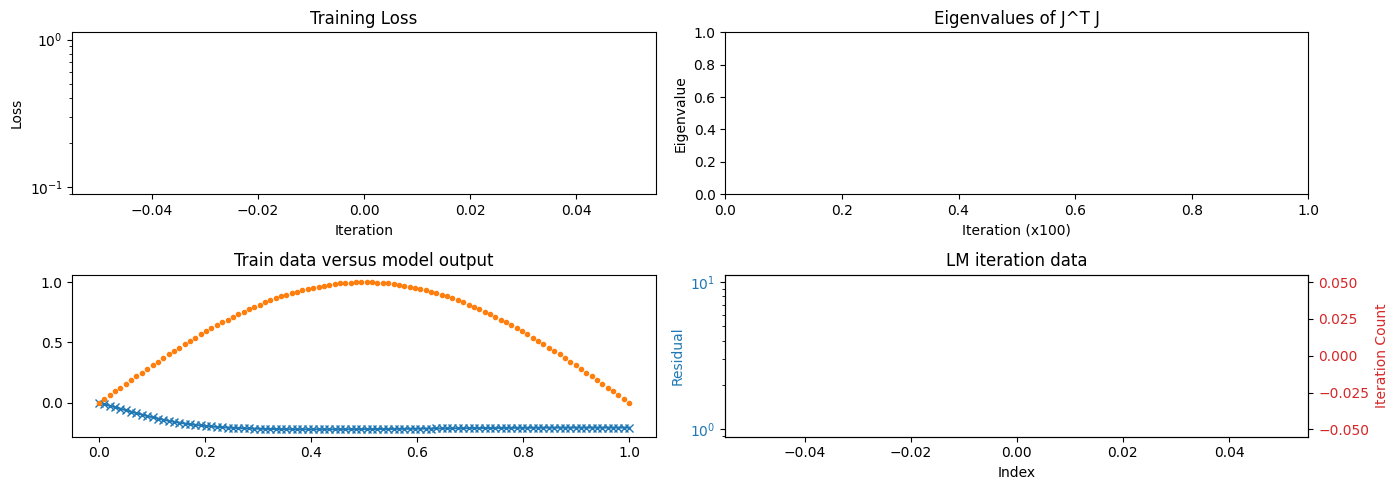

In [40]:
x = jnp.linspace(0, 1, 100).reshape(-1, 1)
y = jnp.sin(1  * jnp.pi * x)
# model = MLP(num_layers=8,hidden_dim=24)
model = MLP(num_layers=4,hidden_dim=10)
key = jax.random.PRNGKey(0)
lm_info = PrecondData(
    method='gn-exact', epoch=0, lamb=1e-1,
    # thresh=1e-1
    # key=key
)

state = create_train_state(model, learning_rate=1e-2, momentum=0, optimizer='sgd')
state, metrics_history = train_model(state, x, y, num_iterations=1, obtain_matrices=False, 
                                     lm_schedule=lm_info,
                                    )
plot_results(state, metrics_history, x, y)

# print(model.tabulate(
#     jax.random.key(0), x, compute_flops=True, compute_vjp_flops=True
# ))
# 

  0%|          | 0/5000 [00:00<?, ?it/s]

Running gn-exact
Running gn-exact


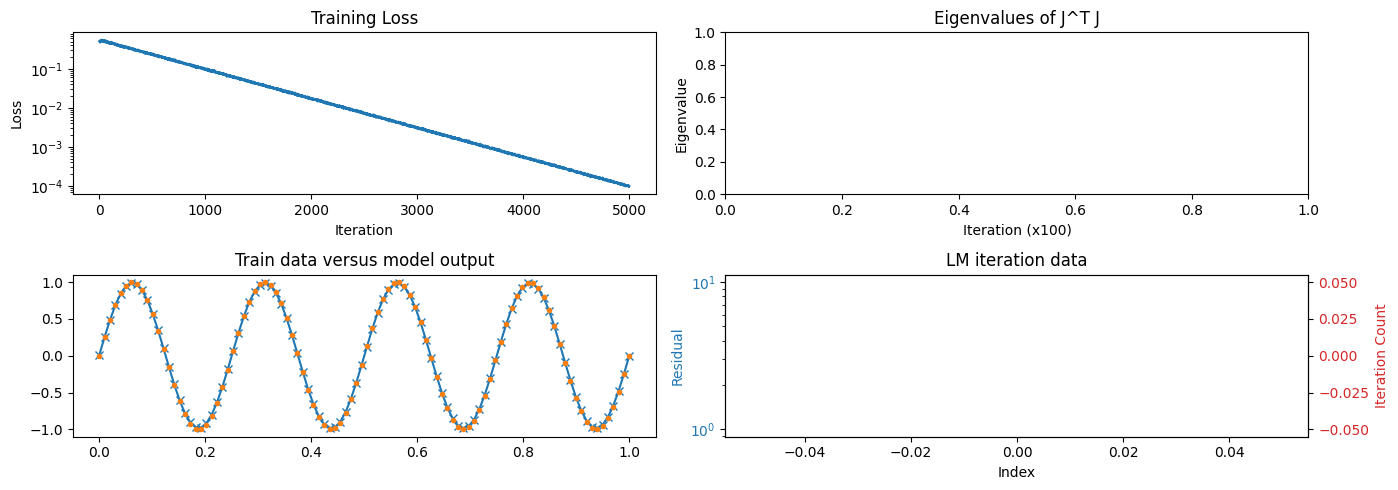

In [19]:
x = jnp.linspace(0, 1, 100).reshape(-1, 1)
y = jnp.sin(8  * jnp.pi * x)
# model = MLP(num_layers=8,hidden_dim=24)
model = MLP(num_layers=4,hidden_dim=10)
key = jax.random.PRNGKey(0)
lm_info = PrecondData(
    method='gn-exact', epoch=0, lamb=1e-1,
    # thresh=1e-1
    # key=key
)

state = create_train_state(model, learning_rate=1e-2, momentum=0, optimizer='sgd')
state, metrics_history_high = train_model(state, x, y, num_iterations=5000, obtain_matrices=False, 
                                     lm_schedule=lm_info,
                                    )
plot_results(state, metrics_history_high, x, y)

# print(model.tabulate(
#     jax.random.key(0), x, compute_flops=True, compute_vjp_flops=True
# ))
# 

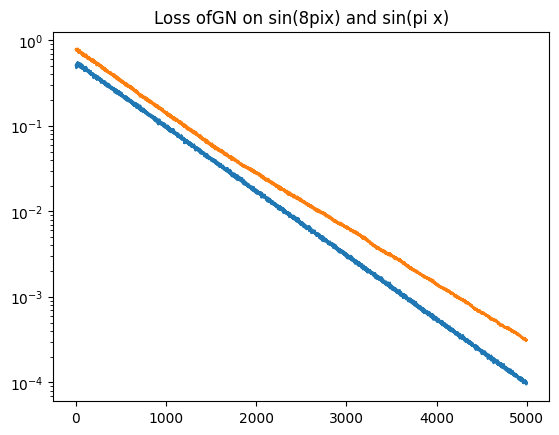

In [20]:
plt.semilogy(metrics_history_high['train_loss'])
plt.semilogy(metrics_history['train_loss'])
plt.title('Loss ofGN on sin(8pix) and sin(pi x)')
plt.show()

In [32]:
x = jnp.linspace(0, 1, 100).reshape(-1, 1)
y = jnp.sin(8  * jnp.pi * x)
# model = MLP(num_layers=8,hidden_dim=24)
model = MLP(num_layers=2,hidden_dim=80)
lm_info = PrecondData(
    method='gn-exact', epoch=0
)
state = create_train_state(model, learning_rate=1e-2, momentum=0, optimizer='sgd')
state, metrics_history = train_model(state, x, y, num_iterations=500, obtain_matrices=False, 
                                     lm_schedule=lm_info
                                    )
plot_results(state, metrics_history, x, y)

# print(model.tabulate(
#     jax.random.key(0), x, compute_flops=True, compute_vjp_flops=True
# ))
# 

  0%|          | 0/500 [00:00<?, ?it/s]

Running gn-exact
Running gn-exact


KeyboardInterrupt: 

  0%|          | 0/5000 [00:00<?, ?it/s]

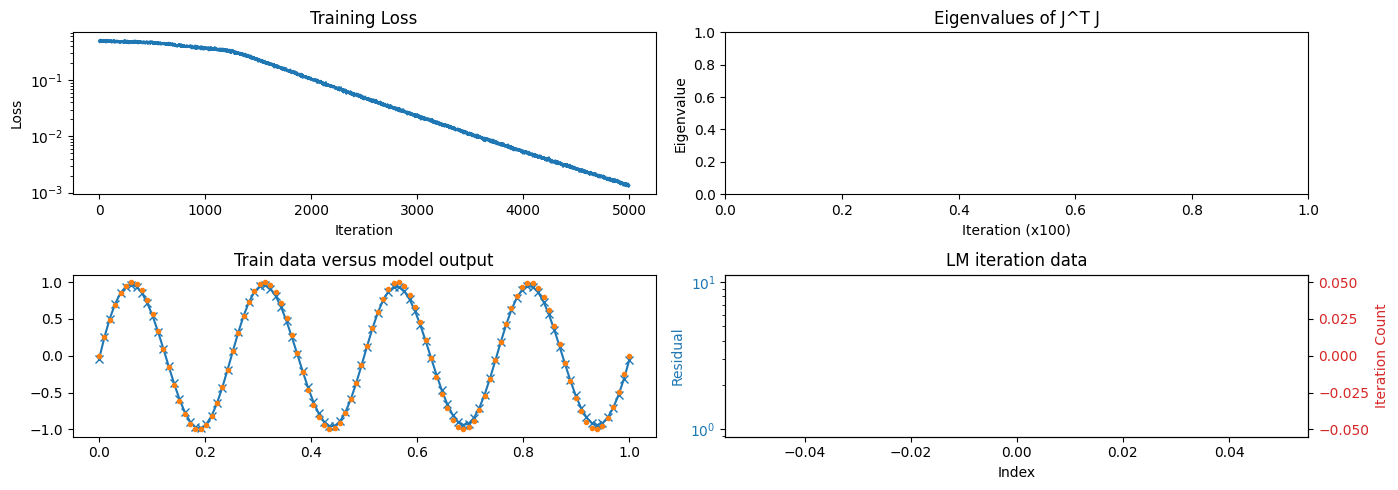

In [155]:
x = jnp.linspace(0, 1, 100).reshape(-1, 1)
y = jnp.sin(8  * jnp.pi * x)
# model = MLP(num_layers=8,hidden_dim=24)
model = MLP(num_layers=1,hidden_dim=90)
state = create_train_state(model, learning_rate=1e-2, momentum=0, optimizer='sgd')
state, metrics_history = train_model(state, x, y, num_iterations=5000, obtain_matrices=False, 
                                     lm_schedule={'epoch': 0, 'lambda': 5e-4, 'max_iter': 50})
plot_results(state, metrics_history, x, y)

# print(model.tabulate(
#     jax.random.key(0), x, compute_flops=True, compute_vjp_flops=True
# ))
# 

  0%|          | 0/5000 [00:00<?, ?it/s]

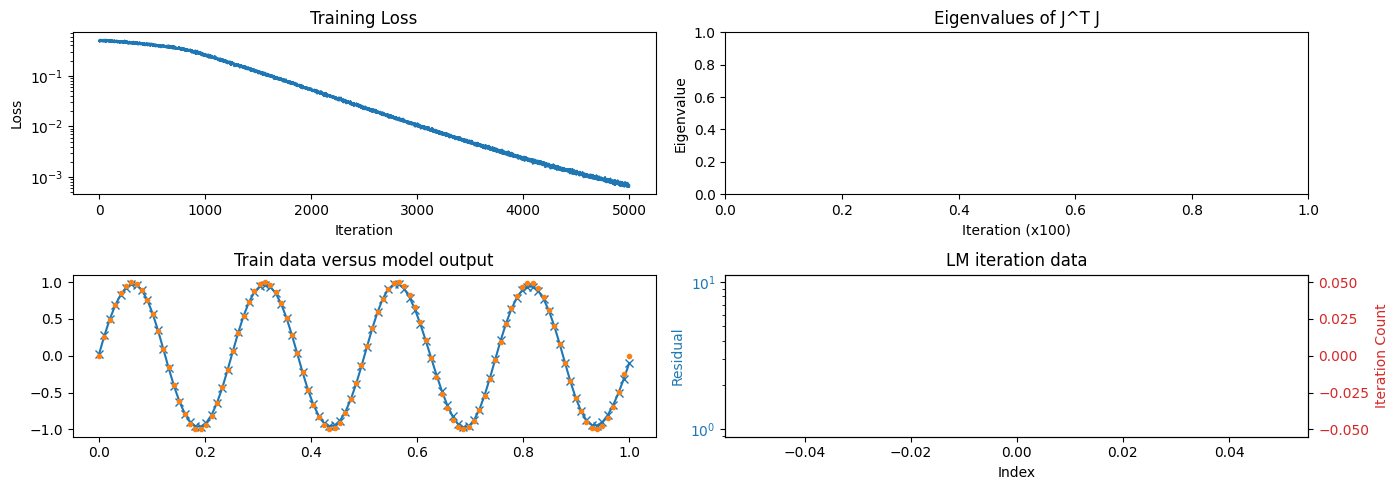

In [139]:
x = jnp.linspace(0, 1, 100).reshape(-1, 1)
y = jnp.sin(8  * jnp.pi * x)
# model = MLP(num_layers=8,hidden_dim=24)
model = MLP(num_layers=2,hidden_dim=80)
state = create_train_state(model, learning_rate=1e-2, momentum=0, optimizer='sgd')
state, metrics_history = train_model(state, x, y, num_iterations=5000, obtain_matrices=False, 
                                     lm_schedule={'epoch': 0, 'lambda': 1e-2, 'max_iter': 50})
plot_results(state, metrics_history, x, y)

# print(model.tabulate(
#     jax.random.key(0), x, compute_flops=True, compute_vjp_flops=True
# ))
# 

  0%|          | 0/10000 [00:00<?, ?it/s]

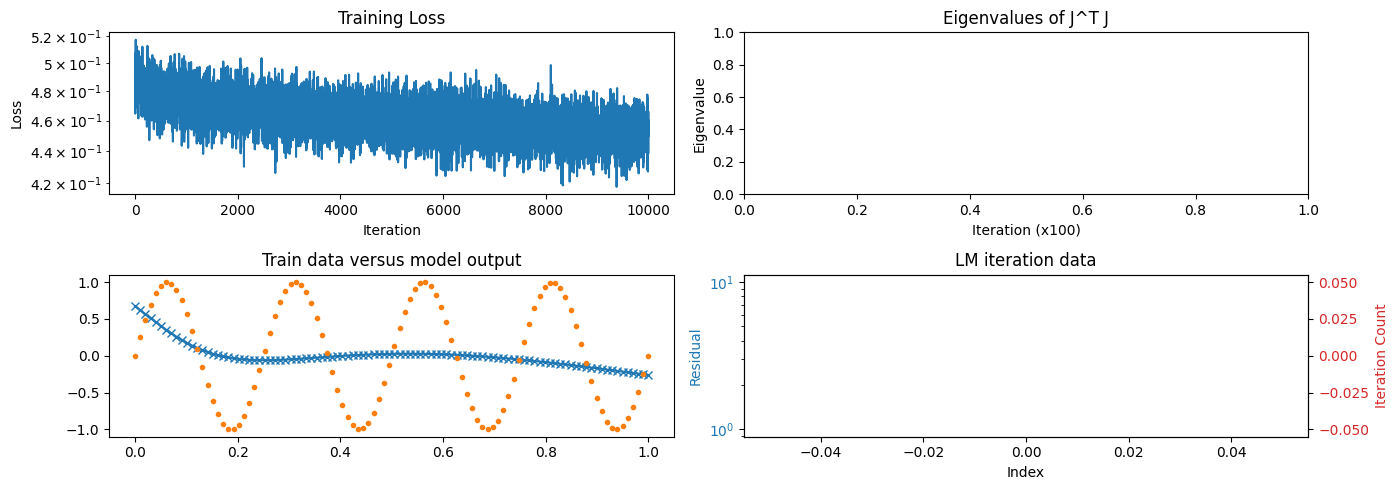

In [143]:
x = jnp.linspace(0, 1, 100).reshape(-1, 1)
y = jnp.sin(8  * jnp.pi * x)
# model = MLP(num_layers=8,hidden_dim=24)
model = MLP(num_layers=2,hidden_dim=80)

state = create_train_state(model, learning_rate=1e-3, momentum=0, optimizer='sgd')
state, metrics_history = train_model(state, x, y, num_iterations=10000, obtain_matrices=False, 
                                     lm_schedule=None #{'epoch': 0, 'lambda': 1e-1, 'max_iter': 50}
                                    )
plot_results(state, metrics_history, x, y)

# print(model.tabulate(
#     jax.random.key(0), x, compute_flops=True, compute_vjp_flops=True
# ))


  0%|          | 0/5000 [00:00<?, ?it/s]

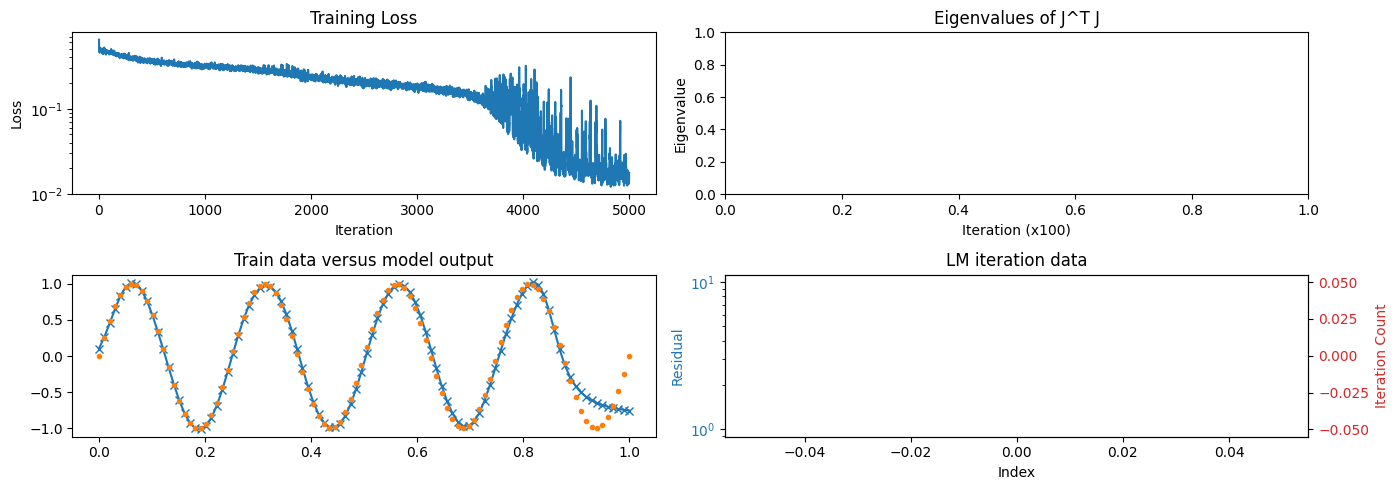

In [46]:
x = jnp.linspace(0, 1, 100).reshape(-1, 1)
y = jnp.sin(8  * jnp.pi * x)
model = MLP(num_layers=8,hidden_dim=24)
state = create_train_state(model, learning_rate=1e-2, momentum=0, optimizer='sgd')
state, metrics_history = train_model(state, x, y, num_iterations=5000, obtain_matrices=False, 
                                     lm_schedule=None)
plot_results(state, metrics_history, x, y)

  0%|          | 0/5000 [00:00<?, ?it/s]

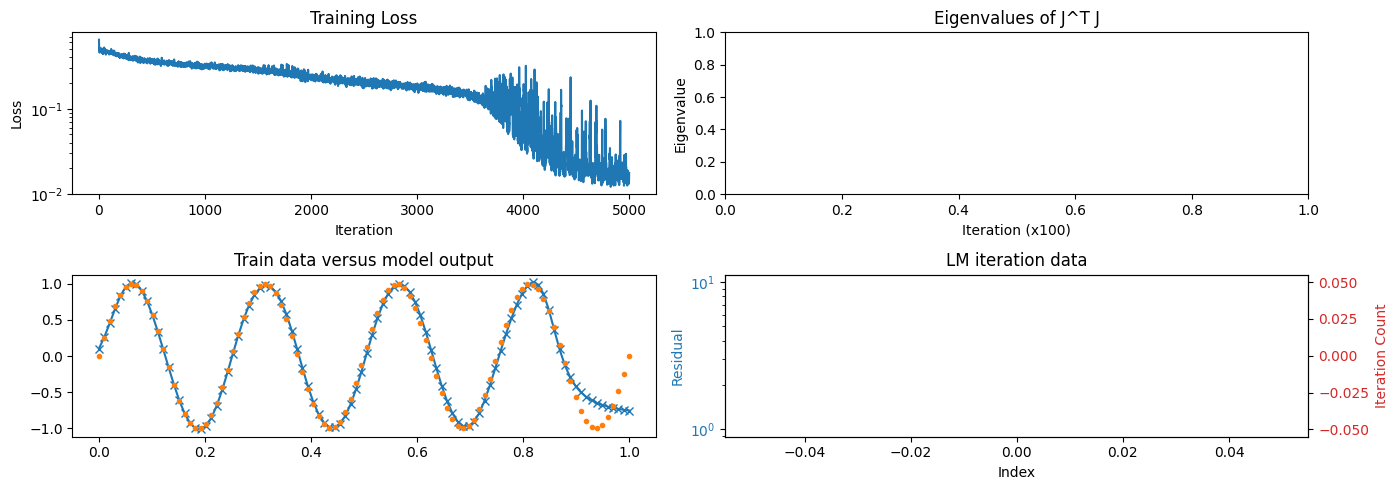

In [13]:
x = jnp.linspace(0, 1, 100).reshape(-1, 1)
y = jnp.sin(8  * jnp.pi * x)
model = MLP(num_layers=8,hidden_dim=24)
state = create_train_state(model, learning_rate=1e-2, momentum=0, optimizer='sgd')
state, metrics_history = train_model(state, x, y, num_iterations=5000, obtain_matrices=False, 
                                     )
plot_results(state, metrics_history, x, y)



  0%|          | 0/2000 [00:00<?, ?it/s]

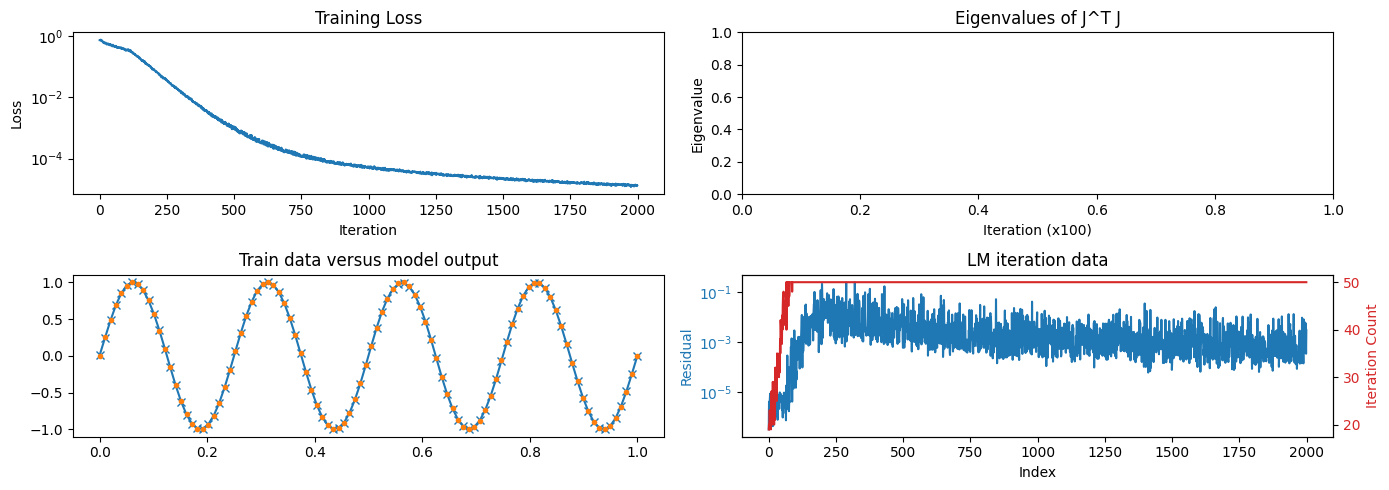


                                  MLP Summary                                   
┏━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━┓
┃ path    ┃ module ┃ inputs     ┃ outputs     ┃ flops ┃ vjp_flops ┃ params     ┃
┡━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━┩
│         │ MLP    │ float32[1… │ float32[10… │ 0     │ 0         │            │
├─────────┼────────┼────────────┼─────────────┼───────┼───────────┼────────────┤
│ Dense_0 │ Dense  │ float32[1… │ float32[10… │ 0     │ 0         │ bias:      │
│         │        │            │             │       │           │ float32[2… │
│         │        │            │             │       │           │ kernel:    │
│         │        │            │             │       │           │ float32[1… │
│         │        │            │             │       │           │            │
│         │        │            │             │       │           │ 48 (192 B) │
├─────────┼────────┼───────

In [14]:
x = jnp.linspace(0, 1, 100).reshape(-1, 1)
y = jnp.sin(8  * jnp.pi * x)
model = MLP(num_layers=8,hidden_dim=24)
state = create_train_state(model, learning_rate=1e-2, momentum=.9, optimizer='sgd')
state, metrics_history = train_model(state, x, y, num_iterations=2000, obtain_matrices=False, 
                                     lm_schedule={'epoch': 0, 'lambda': 1e-1, 'max_iter': 50})
plot_results(state, metrics_history, x, y)

print(model.tabulate(
    jax.random.key(0), x, compute_flops=True, compute_vjp_flops=True
))


  0%|          | 0/10000 [00:00<?, ?it/s]

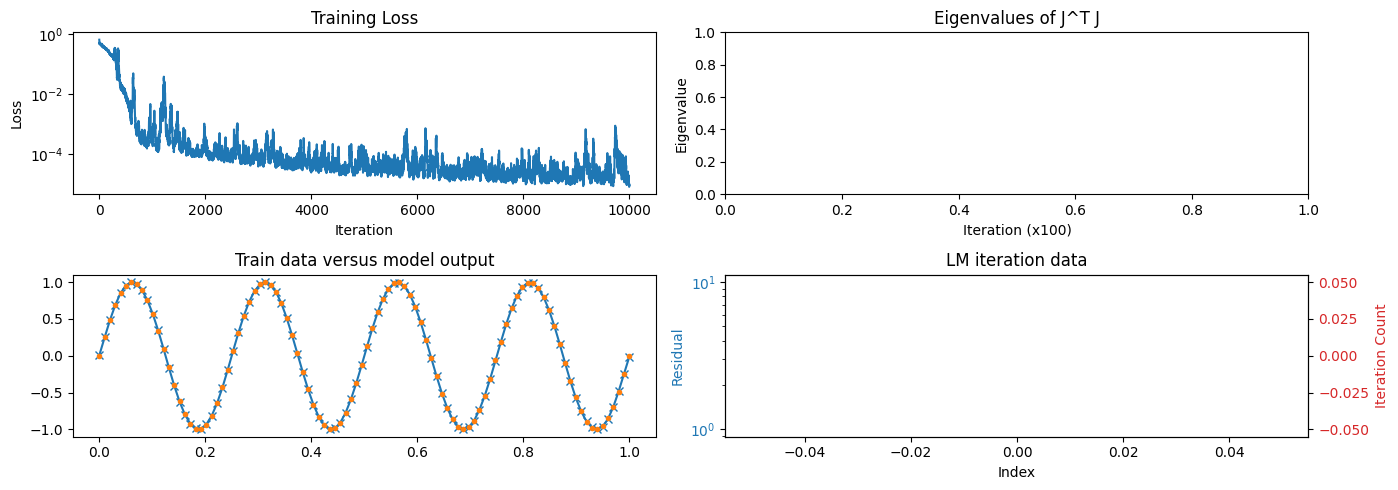

In [15]:
x = jnp.linspace(0, 1, 100).reshape(-1, 1)
y = jnp.sin(8  * jnp.pi * x)
model = MLP(num_layers=8,hidden_dim=24)
state = create_train_state(model, learning_rate=1e-2, momentum=0.9, optimizer='sgd')
state, metrics_history = train_model(state, x, y, num_iterations=10000, obtain_matrices=False)
plot_results(state, metrics_history, x, y)

# print(model.tabulate(
#     jax.random.key(0), x, compute_flops=True, compute_vjp_flops=True
# ))



Next, some Adam/AdamW; here it's VERY good. Though it seems switching incurs a jump in loss. 

  0%|          | 0/200 [00:00<?, ?it/s]

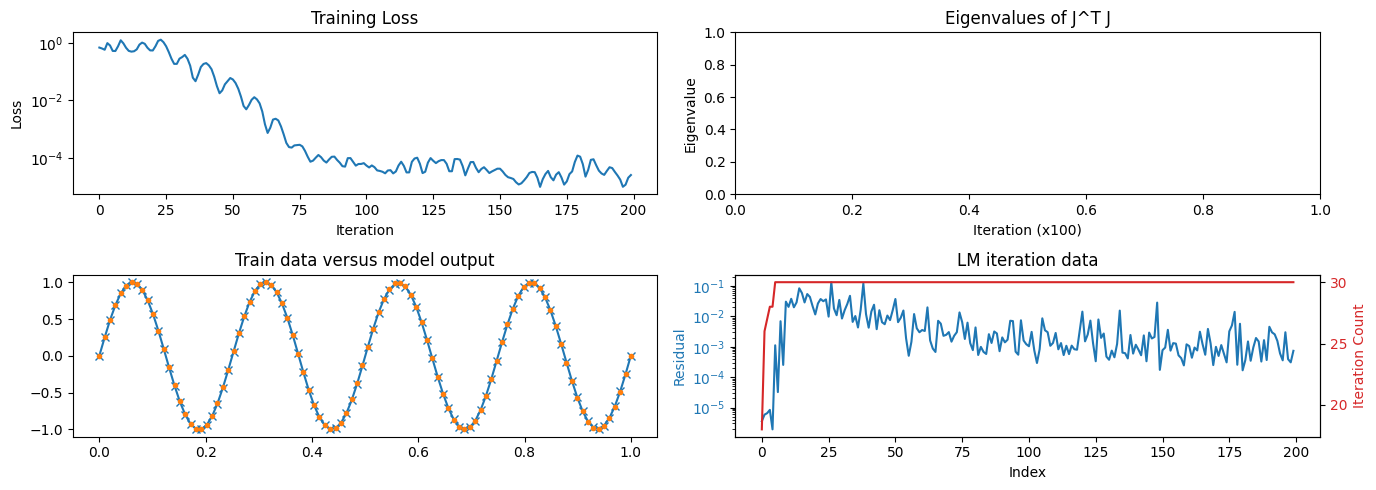

In [17]:
x = jnp.linspace(0, 1, 100).reshape(-1, 1)
y = jnp.sin(8  * jnp.pi * x)
model = MLP(num_layers=8,hidden_dim=24)
state = create_train_state(model, learning_rate=1e-2, momentum=0, optimizer='adamw')
state, metrics_history = train_model(state, x, y, num_iterations=200, obtain_matrices=False, 
                                     lm_schedule={'epoch': 0, 'lambda': 1e-1, 'max_iter': 30})
plot_results(state, metrics_history, x, y)

# print(model.tabulate(
#     jax.random.key(0), x, compute_flops=True, compute_vjp_flops=True
# ))


  0%|          | 0/1000 [00:00<?, ?it/s]

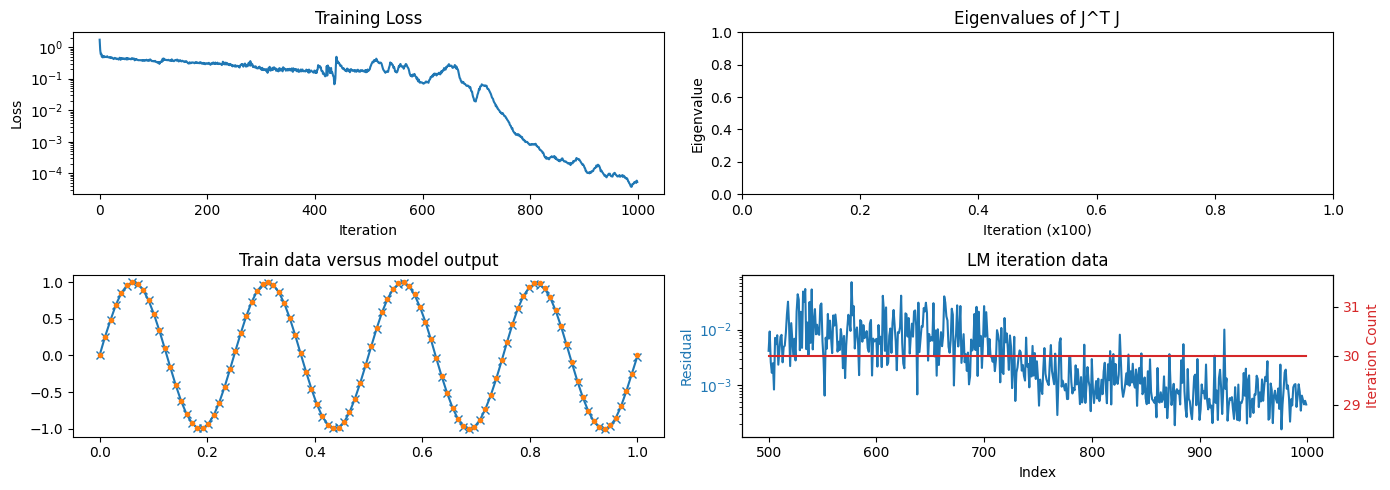

In [18]:
# When using this, it might be necessary to change some of the optimizer state!
x = jnp.linspace(0, 1, 100).reshape(-1, 1)
y = jnp.sin(8  * jnp.pi * x)
model = MLP(num_layers=8,hidden_dim=24)
state = create_train_state(model, learning_rate=1e-2, momentum=0, optimizer='adamw')
state, metrics_history = train_model(state, x, y, num_iterations=1000, obtain_matrices=False, 
                                     lm_schedule={'epoch': 500, 'lambda': 1e-1, 'max_iter': 30})
plot_results(state, metrics_history, x, y)


  0%|          | 0/3000 [00:00<?, ?it/s]

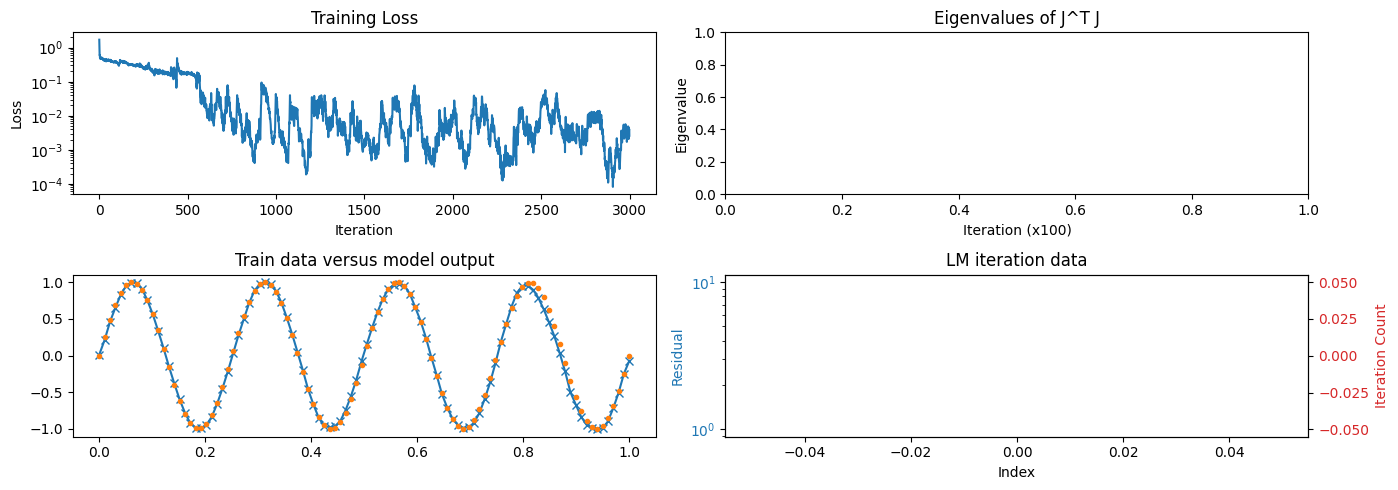

In [19]:
x = jnp.linspace(0, 1, 100).reshape(-1, 1)
y = jnp.sin(8  * jnp.pi * x)
model = MLP(num_layers=8,hidden_dim=24)
state = create_train_state(model, learning_rate=1e-2,optimizer='adamw')
state, metrics_history = train_model(state, x, y, num_iterations=3000, obtain_matrices=False)
plot_results(state, metrics_history, x, y)
# print(model.tabulate(
#     jax.random.key(0), x, compute_flops=True, compute_vjp_flops=True
# ))


  0%|          | 0/500 [00:00<?, ?it/s]

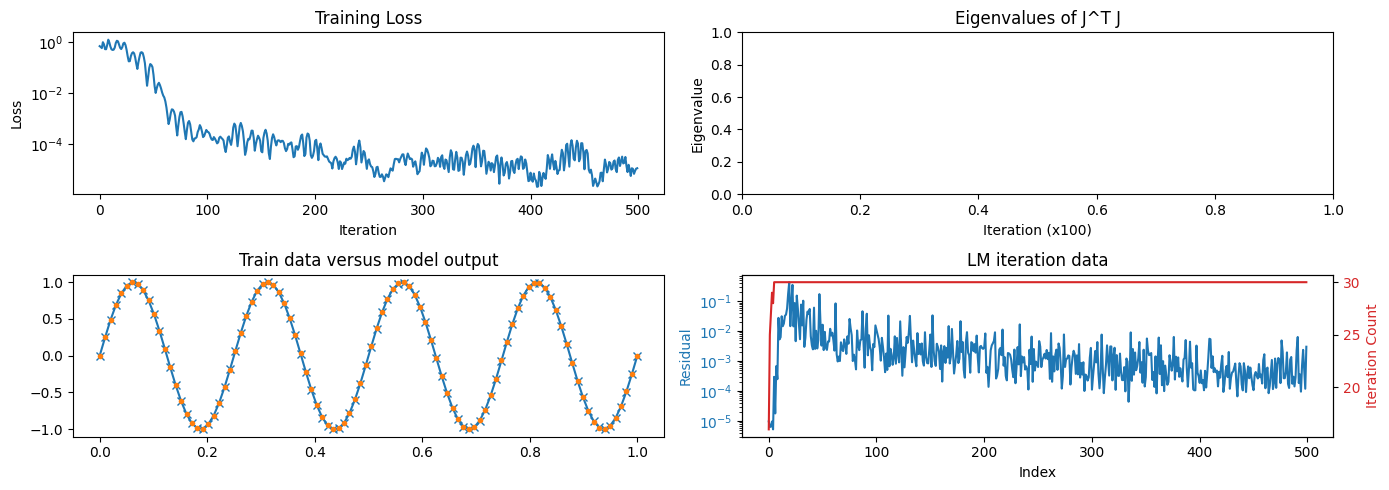

In [20]:
x = jnp.linspace(0, 1, 100).reshape(-1, 1)
y = jnp.sin(8  * jnp.pi * x)
model = MLP(num_layers=8,hidden_dim=24)
state = create_train_state(model, learning_rate=1e-2, momentum=0, optimizer='adam')
state, metrics_history = train_model(state, x, y, num_iterations=500, obtain_matrices=False, 
                                     lm_schedule={'epoch': 0, 'lambda': 1e-1, 'max_iter': 30})
plot_results(state, metrics_history, x, y)

# print(model.tabulate(
#     jax.random.key(0), x, compute_flops=True, compute_vjp_flops=True
# ))


  0%|          | 0/3000 [00:00<?, ?it/s]

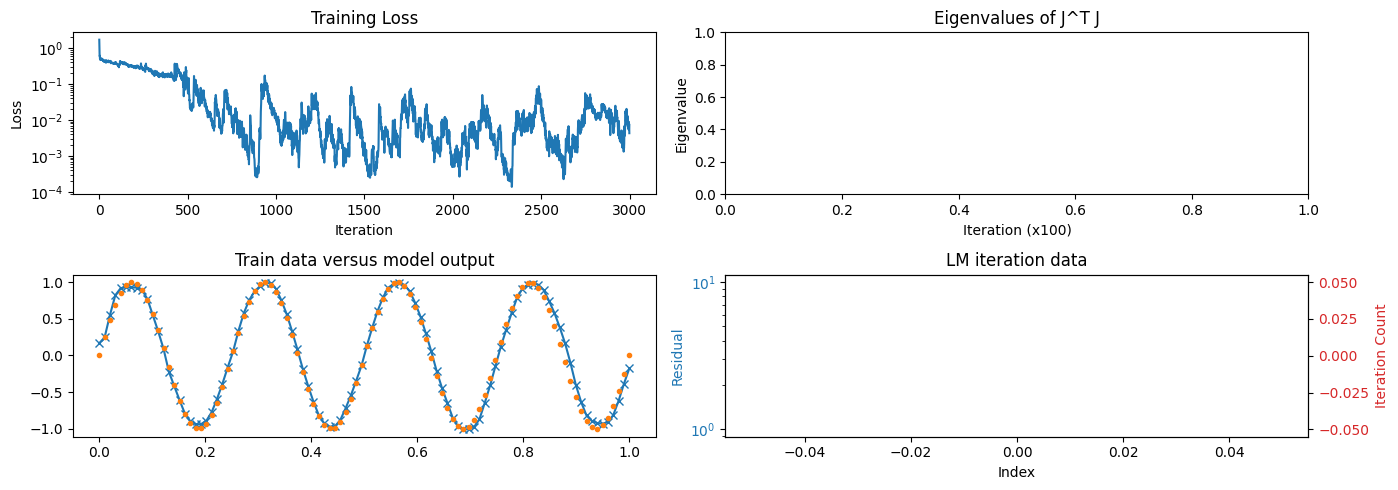

In [21]:
x = jnp.linspace(0, 1, 100).reshape(-1, 1)
y = jnp.sin(8  * jnp.pi * x)
model = MLP(num_layers=8,hidden_dim=24)
state = create_train_state(model, learning_rate=1e-2,optimizer='adam')
state, metrics_history = train_model(state, x, y, num_iterations=3000, obtain_matrices=False)
plot_results(state, metrics_history, x, y)
# print(model.tabulate(
#     jax.random.key(0), x, compute_flops=True, compute_vjp_flops=True
# ))


  0%|          | 0/75 [00:00<?, ?it/s]

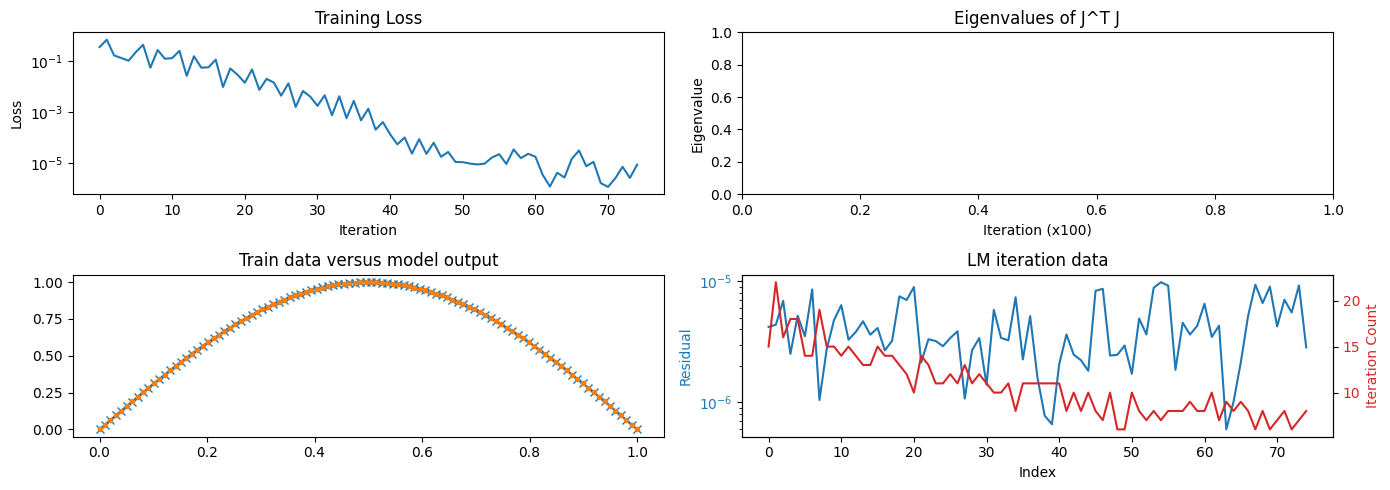

In [22]:
x = jnp.linspace(0, 1, 100).reshape(-1, 1)
y = jnp.sin(jnp.pi * x)
model = MLP(num_layers=8,hidden_dim=24)
state = create_train_state(model, learning_rate=1e-2, momentum=0, optimizer='adamw')
state, metrics_history = train_model(state, x, y, num_iterations=75, obtain_matrices=False, 
                                     lm_schedule={'epoch': 0, 'lambda': 1e-1, 'max_iter': 30})
plot_results(state, metrics_history, x, y)

# print(model.tabulate(
#     jax.random.key(0), x, compute_flops=True, compute_vjp_flops=True
# ))


  0%|          | 0/1000 [00:00<?, ?it/s]

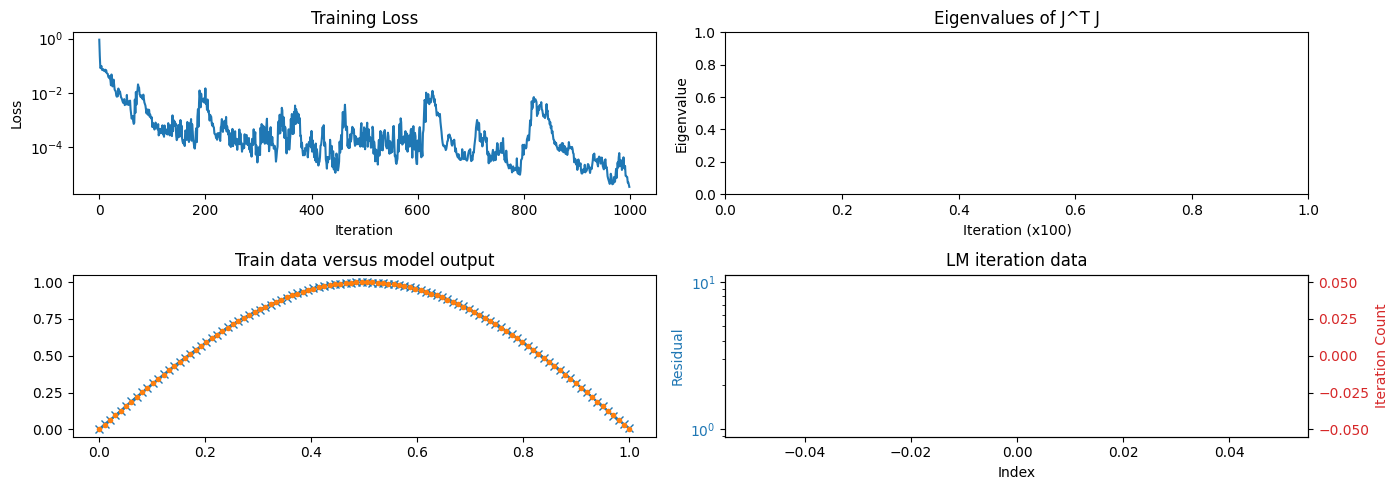

In [23]:
x = jnp.linspace(0, 1, 100).reshape(-1, 1)
y = jnp.sin(jnp.pi * x)
model = MLP(num_layers=8,hidden_dim=24)
state = create_train_state(model, learning_rate=1e-2, momentum=0, optimizer='adamw')
state, metrics_history = train_model(state, x, y, num_iterations=1000, obtain_matrices=False, 
                                     )
plot_results(state, metrics_history, x, y)

# print(model.tabulate(
#     jax.random.key(0), x, compute_flops=True, compute_vjp_flops=True
# ))
